In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split


In [6]:

DATA_PATH = Path('../data/processed/transport_processed.csv')
df = pd.read_csv(DATA_PATH)

X = df.select_dtypes(include=['number', 'bool']).drop(columns=['actual_arrival_delay_min', 'delayed'])
y_reg = df['actual_arrival_delay_min']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)


rfg = joblib.load('../models/rfg_model.pkl')

<Axes: xlabel='importance', ylabel='features'>

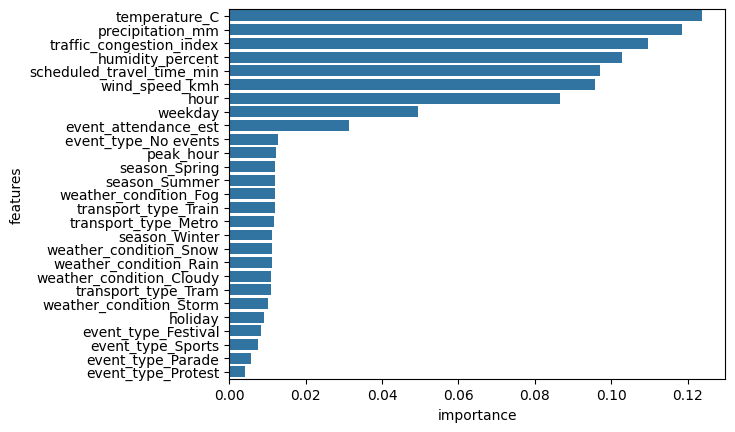

In [7]:
new_df=pd.DataFrame({'features':X.columns,'importance':rfg.feature_importances_}).sort_values(by='importance',ascending= False)
sns.barplot(data=new_df,x='importance',y='features')